# VisXAI: Real Pretrained Checkpoint Demo (Hugging Face)

Every other demo notebook in this repo (`tree_demo.ipynb`,
`sequence_demo.ipynb`, `graph_demo.ipynb`) trains a small model from
scratch, entirely offline. This notebook is different on purpose: it
loads a **real, publicly-hosted pretrained checkpoint** —
[`seyonec/ChemBERTa-zinc-base-v1`](https://huggingface.co/seyonec/ChemBERTa-zinc-base-v1),
a RoBERTa-architecture model pretrained on SMILES strings — via
`visxai.models.hf_wrapper`, and explains a prediction with it.

**This notebook requires internet access** (to download the checkpoint,
once, on first run) and is **not** part of the offline notebook run; it downloads a real checkpoint the first time it is executed.

**Important caveat, stated up front:** `ChemBERTa-zinc-base-v1` is a
*masked-language-model* checkpoint — it was pretrained to predict masked
SMILES tokens, not fine-tuned on any downstream property-prediction task.
Loading it with `AutoModelForSequenceClassification` attaches a **freshly,
randomly initialized** classification head on top of the pretrained
backbone (`transformers` prints a warning saying exactly this). So the
actual **predicted value** below is meaningless — but the **explanation
mechanics** are real: `AttentionExplainer`/`IntegratedGradientsExplainer`
compute exactly what a genuinely fine-tuned checkpoint's explanation would
look like, mechanically. The point of this notebook is to demonstrate the
*pipeline* working against a real HF model, not to produce a scientifically
meaningful aspirin explanation — for that, you'd swap in a checkpoint
actually fine-tuned on a real property-prediction task.

In [1]:
from IPython.display import SVG, display
from transformers import AutoModelForSequenceClassification

from visxai.explainers.attention import AttentionExplainer
from visxai.explainers.gradient_based_sequence import IntegratedGradientsExplainer
from visxai.features.sequences import generate_sequence_representation
from visxai.models.hf_wrapper import load_pretrained_sequence_model
from visxai.visualizers.rdkit_2d import RDKitSVGVisualizer

_CHECKPOINT = "seyonec/ChemBERTa-zinc-base-v1"


## Loading the checkpoint

`load_pretrained_sequence_model(checkpoint, model_class, **model_kwargs)`
loads `AutoTokenizer.from_pretrained(checkpoint)` and
`model_class.from_pretrained(checkpoint, **model_kwargs)`, then returns a
ready `(PyTorchSequenceWrapper, HFTokenizerAdapter)` pair — no separate
wrapper class needed, since a real HF model's own
`forward(input_ids=..., attention_mask=...)` calling convention already
matches `PyTorchSequenceWrapper`'s.

`model_class` (here, `AutoModelForSequenceClassification`) is a
**required** argument with no default — VisXAI never guesses a
model-specific detail on the caller's behalf (the same principle behind
`atom_featurizer`/`target_layer`/`embedding_layer` having no defaults
elsewhere in this package), and a real checkpoint's task head genuinely
varies (classification, regression, masked-LM-only with no head at all,
as is the case here).

In [2]:
wrapper, tokenizer = load_pretrained_sequence_model(
    _CHECKPOINT, AutoModelForSequenceClassification, num_labels=1
)
print(f"Loaded {_CHECKPOINT}")
print(f"  backbone parameters: {sum(p.numel() for p in wrapper.model.parameters()):,}")
print(f"  vocab size:          {wrapper.model.config.vocab_size}")


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at seyonec/ChemBERTa-zinc-base-v1 and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Loaded seyonec/ChemBERTa-zinc-base-v1
  backbone parameters: 44,104,705
  vocab size:          767


## Explaining aspirin with attention

`tokenizer` (an `HFTokenizerAdapter`) satisfies the same `SMILESTokenizer`
protocol as VisXAI's own built-in reference tokenizer, so it plugs
straight into `generate_sequence_representation(tokenizer=...)` — nothing
downstream needs to know this came from a real HF tokenizer rather than a
hand-rolled one.

RobertaSdpaSelfAttention is used but `torch.nn.functional.scaled_dot_product_attention` does not support non-absolute `position_embedding_type` or `output_attentions=True` or `head_mask`. Falling back to the manual attention implementation, but specifying the manual implementation will be required from Transformers version v5.0.0 onwards. This warning can be removed using the argument `attn_implementation="eager"` when loading the model.


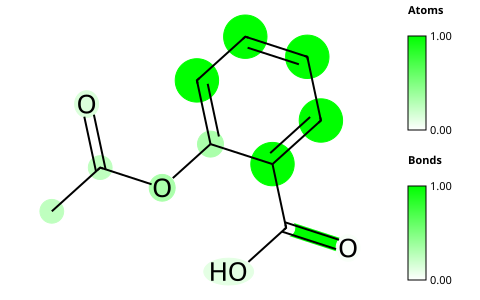

atoms scored: 13 / 13
bonds scored: 2 / 13
predicted_value: -0.0745  (meaningless -- untrained head, see intro)


In [3]:
mol_rep = generate_sequence_representation("CC(=O)Oc1ccccc1C(=O)O", tokenizer=tokenizer)

att_explanation = AttentionExplainer().explain(wrapper, mol_rep)
display(SVG(RDKitSVGVisualizer().visualize(mol_rep, att_explanation)))

print(f"atoms scored: {len(att_explanation.atom_scores)} / {mol_rep.mol.GetNumAtoms()}")
print(f"bonds scored: {len(att_explanation.bond_scores)} / {mol_rep.mol.GetNumBonds()}")
print(f"predicted_value: {att_explanation.metadata['predicted_value']:.4f}  (meaningless -- untrained head, see intro)")


## Explaining aspirin with Integrated Gradients

Gradient-based explainers work against a real checkpoint the same way —
`embedding_layer` just needs to point at the real model's own embedding
submodule (`wrapper.model.roberta.embeddings.word_embeddings` for this
architecture; the exact attribute path depends on the checkpoint's model
class, which is exactly why `embedding_layer` is a required, explicit
argument rather than something VisXAI tries to auto-detect).

**`GradCAMExplainer` (the sequence-path one) does *not* apply here** —
it requires a `Conv1d` `target_layer`, and this RoBERTa-architecture
checkpoint has none (confirmed: zero `Conv1d` submodules anywhere in the
model). See `sequence_demo.ipynb`'s CNN section for a working
`GradCAMExplainer` example instead — Grad-CAM here is specifically for
convolutional sequence models, not attention-only Transformers.

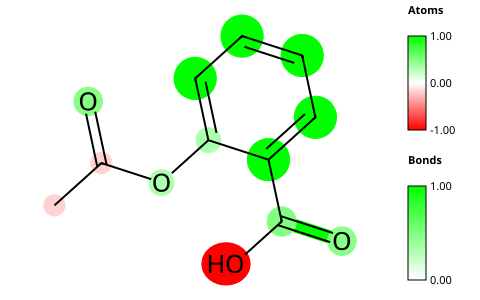

atoms scored: 13 / 13
bonds scored: 2 / 13
metadata: {'n_steps': 50, 'predicted_value': -0.07446277141571045}


In [4]:
ig_explainer = IntegratedGradientsExplainer(
    embedding_layer=wrapper.model.roberta.embeddings.word_embeddings,
    n_steps=50,
)
ig_explanation = ig_explainer.explain(wrapper, mol_rep)
display(SVG(RDKitSVGVisualizer().visualize(mol_rep, ig_explanation)))

print(f"atoms scored: {len(ig_explanation.atom_scores)} / {mol_rep.mol.GetNumAtoms()}")
print(f"bonds scored: {len(ig_explanation.bond_scores)} / {mol_rep.mol.GetNumBonds()}")
print(f"metadata: {ig_explanation.metadata}")


## A real `transformers` gotcha, found while building this

`AttentionExplainer` needs `output_attentions=True`. On the `transformers`
version this was tested against, requesting that from an `"sdpa"`-attention
model (this checkpoint's default, and most modern architectures') triggers
an automatic runtime fallback to eager attention — with a `UserWarning`
you'll see printed above. Verified this fallback still returns real,
correct per-layer attention tensors, not empty ones. But the warning
itself says this fallback is **removed in `transformers` v5.0.0** — at
that point, requesting attentions from an `"sdpa"`-implementation model
may raise instead of silently falling back.

To sidestep this entirely (and get a clean run with no warning), pass
`attn_implementation="eager"` through to the loader:

In [5]:
eager_wrapper, eager_tokenizer = load_pretrained_sequence_model(
    _CHECKPOINT,
    AutoModelForSequenceClassification,
    num_labels=1,
    attn_implementation="eager",
)
eager_mol_rep = generate_sequence_representation("CCO", tokenizer=eager_tokenizer)
eager_explanation = AttentionExplainer().explain(eager_wrapper, eager_mol_rep)
print("No fallback warning above this line -- ran directly in eager mode.")
print("atom_scores:", eager_explanation.atom_scores)


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at seyonec/ChemBERTa-zinc-base-v1 and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


No fallback warning above this line -- ran directly in eager mode.
atom_scores: {0: 0.5533316135406494, 1: 0.5533316135406494, 2: 0.5533316135406494}


## Next steps

- Swap `_CHECKPOINT` for a real checkpoint actually fine-tuned on a
  property-prediction task to get a scientifically meaningful explanation
  instead of this notebook's illustrative-only one.
- `load_pretrained_sequence_model`'s `**model_kwargs` forwards to
  `model_class.from_pretrained(...)` directly — anything that constructor
  accepts (`num_labels`, `attn_implementation`, `torch_dtype`, etc.) works
  here too.
- See `sequence_demo.ipynb` for `GradCAMExplainer` (needs a `Conv1d`
  model, trained from scratch there) and both aggregation strategies of
  `AttentionExplainer`.